<a href="https://colab.research.google.com/github/ewarren38/HW5_WarrenE/blob/main/HW5_WarrenE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Homework 5**
**Author:** Eleanor Warren

**Course:** ST554-601

**Purpose:** Complete HW 5

**Date:** 3.3.2026

##**Part 1 | Concepts**

### 1. When have I encountered big data?
**The 5 V's: Volume, Velocity, Variety, Variability, Value**

I worked with large datasets often over the 5 years I worked supporting economic research as a research assistant and financial analyst, but I wouldn't say that they rose to the level of "big data". Some of the data I worked with was public data to support economic research. When trying to do research on population characteristics (say you're interested in household-level information in the U.S.), that requires millions of data points. Then you layer on a time dimension, because economists very often want to assess a relationship or effect over time. To some degree, you could say that's a large "volume" of data, especially since we keep this information indefinitely as a public archive, but it's nowhere close to the kind of data you get from monitoring everyone's cell-phone habits, for example.

Also, for government-collected public datasets, the velocity is not very "fast". For example, some public datasets are updated monthly or yearly, and with a delayed schedule (data released this month describes information about last month, for example). This is related to the fact that this is information released to the public, so it can't be released in raw form. There is a time delay for people to clean and quality control the data. This quality control can mitigate issues with veracity/variability, because it's already someone's job to have an understanding of what we would expect from this data and to ensure that collection methods are robust.

Although there is a lot of variety in the content of information government datasets contain on households (income, financial behaviors, marital status, health behaviors, etc.) I wouldn't say that public datasets have a lot of variety in the kind of data that's presented. It's primarily numeric or categorical data with characteristics observed on households or the economy, as opposed to different types of formats like numeric data vs. video information.

Lastly, I would say these data have a high value because of how rigorously they are collected and reviewed, and at the scale that it is. Meaning, I would guess that it's costly to collect and maintain this data. It's also "valuable" in the sense that we can investigate important questions that our collective systems might act on in a way that impacts tons of people.

##2. CRUD in `Lahman.db`
**Create, Read, Update, Delete**
This database contains sports statistics on baseball teams dating back to 1871. For this RDBMS, you might want to `CREATE` a new table if there was a new piece of information you wanted to start collecting about teams or players. For example, if you decided that you wanted to know what each player did with their lives post-retirement, you might create a "retirement" table. You would `READ` data if you wanted to grab existing data from the database and run some analyses on them, like chart the fastest pitch speed over time. Maybe there is a baseball team with an offensive team name that decides to update what they are called, then you might `UDPATE` the "team name" variable of the relevant table(s) for that team. Lastly, if you came across some data duplication, that might be an instance where you want to `DELETE` rows or an entire table that you already have in the database.

##3. `HAVING` clause

The `HAVING` clause in SQL's `SELECT` statement serves as a conditional tool, but specifically for grouped data. It works very similarly to the way that `WHERE` filters rows of a table. After you use `GROUP BY` to collapse rows into groups based on the value of a certain variable(s), you can then select certain groups that meet your `HAVING` condition.

#**Part 2 | Simulation of a Sampling Distribution**



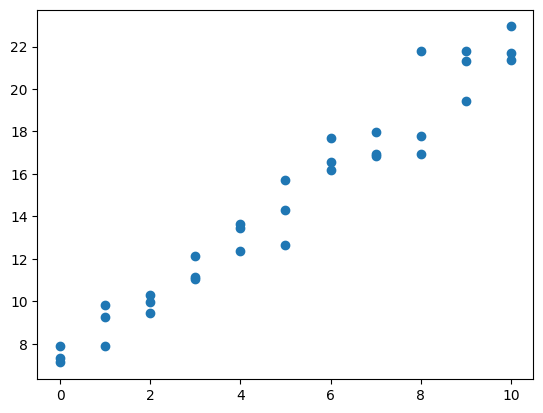

In [18]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5 # get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = 33 #create the 'responses' modeled from the line plus a random deviation
y = beta_0 + beta_1*x + rng.standard_normal(n) #visualize the data
plt.scatter(x = x, y = y)
plt.show()

In [21]:
import pandas as pd
sim_data = pd.DataFrame(zip(x, y), columns = ("x", "y"))
sim_data

,x,y
0,0.0,7.909145
1,1.0,9.251397
2,2.0,9.974462
3,3.0,12.152506
4,4.0,12.349046
5,5.0,12.670508
6,6.0,17.678511
7,7.0,17.976614
8,8.0,16.933652
9,9.0,19.441064


In [24]:
from sklearn import linear_model
reg = linear_model.LinearRegression()
print(reg.intercept_, reg.coef_)


7.259043801350283 [1.47450564]


In [38]:
def beta_distribution(simulations):
  beta_0 = 7
  beta_1 = 1.5
  n = 33
  rng = default_rng(32)
  beta_estimates = []

  for _ in range(simulations+1):
  # get three 'values' of x at each integer from 0 to 10.
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    sim_data = pd.DataFrame(zip(x, y), columns = ("x", "y"))

    reg.fit(sim_data['x'].values.reshape(-1, 1), sim_data['y'])
    beta_hat = reg.coef_
    beta_estimates.append(beta_hat)

  return beta_estimates

[Text(0.5, 0, 'Beta_1 Hat')]

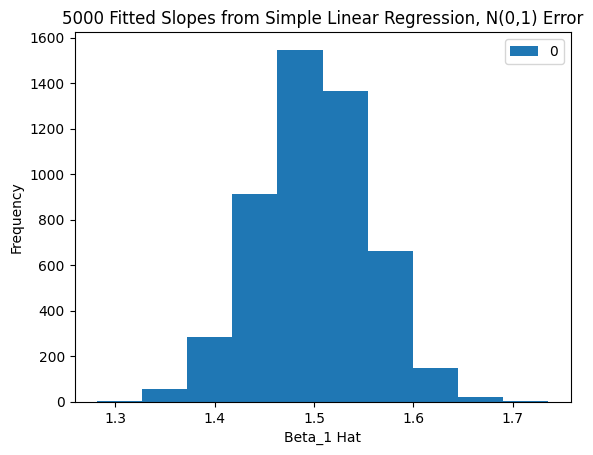

In [53]:
beta_est = pd.DataFrame(beta_distribution(5000))
beta_est.plot.hist(
    title = "5000 Fitted Slopes from Simple Linear Regression, N(0,1) Error")\
    .set(xlabel = "Beta_1 Hat")

In [61]:
# Probability that Beta_1 is greater than 1.65 given our sampling distribution
above_value = [b for b in beta_est[0] if b > 1.65]
probability_value = len(above_value) / len(beta_est[0]) *100
probability_value

0.3799240151969606

We can interpret this value to mean that, on average over repeated samples, we'd only expect to observe a fitted slope value of greater than 1.65 **0.37%** percent of the time. In other words, it's extremely unlikely that we're going to observe a sample with a fitted slope greater than 1.65, if our sampling distribution represents represents the true population distribution for Beta_1 (slope).

##**Part 4 | Querying a Database**


In [122]:
import sqlite3
con = sqlite3.connect("/lahman_1871-2022.sqlite")
get_schema = '''
   SELECT *
   FROM sqlite_schema
   WHERE type = 'table';
   '''
schema_df = pd.read_sql(get_schema, con)
schema_df.iloc[13,4]

'CREATE TABLE HallOfFame (\nplayerID TEXT,\nyearid INTEGER,\nvotedBy TEXT,\nballots INTEGER,\nneeded INTEGER,\nvotes INTEGER,\ninducted TEXT,\ncategory TEXT,\nneeded_note TEXT\n)'

In [79]:
#Make a querying function
def execute_query(connection, query):
    cursor = connection.cursor()
    try:
      cursor.execute(query)
      print("Query executed successfully")
    except Error as e:
      print(f"The error {e} occurred")
    cursor.close()

In [92]:
#all the teams that played in the year 2015 with all of the corresponding columns from the Teams table.
get_2015_teams = '''
  SELECT *
  FROM Teams
  WHERE yearID > 2015
  '''
execute_query(con, get_2015_teams)

teams_2015 = pd.read_sql(get_2015_teams, con)
teams_2015

Query executed successfully


,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,DivWin,WCWin,LgWin,WSWin,R,AB,H,2B,3B,HR,BB,SO,SB,CS,HBP,SF,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,2016,AL,BAL,BAL,E,2,162,81,89,73,N,Y,N,N,744,5524,1413,265,6,253,468,1324,19,13,44,36,715,671,4.22,1,9,54,4296,1408,183,545,1248,80,165,0.987,Baltimore Orioles,Oriole Park at Camden Yards,2172344,101,101,BAL,BAL,BAL
1,2016,AL,BOS,BOS,E,1,162,81,93,69,Y,N,N,N,878,5670,1598,343,25,208,558,1160,83,24,43,40,694,640,4.00,9,5,43,4319,1342,176,490,1362,75,139,0.987,Boston Red Sox,Fenway Park II,2955434,108,106,BOS,BOS,BOS
2,2016,AL,CHA,CHW,C,4,162,81,78,84,N,N,N,N,686,5550,1428,277,33,168,455,1285,77,36,53,44,715,659,4.10,7,10,43,4340,1422,185,521,1270,95,148,0.984,Chicago White Sox,U.S. Cellular Field,1746293,96,97,CHW,CHA,CHA
3,2016,AL,CLE,CLE,C,1,161,80,94,67,Y,N,Y,N,777,5484,1435,308,29,185,531,1246,134,31,49,60,676,617,3.84,5,11,37,4335,1330,186,461,1398,89,126,0.985,Cleveland Indians,Progressive Field,1591667,110,109,CLE,CLE,CLE
4,2016,AL,DET,DET,C,2,161,81,86,75,N,N,N,N,750,5526,1476,252,30,211,493,1303,58,29,53,38,721,672,4.24,3,8,47,4284,1417,182,462,1232,75,148,0.987,Detroit Tigers,Comerica Park,2493859,101,101,DET,DET,DET
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,2022,NL,PIT,PIT,C,5,162,81,62,100,N,N,N,N,591,5331,1186,221,29,158,476,1497,89,32,54,32,817,735,4.66,0,6,33,4263,1432,164,586,1250,121,152,0.979,Pittsburgh Pirates,PNC Park,1257458,100,102,PIT,PIT,PIT
206,2022,NL,SDN,SDP,W,2,162,81,89,73,N,Y,N,N,705,5468,1317,275,18,153,574,1327,49,22,65,46,660,611,3.81,0,15,48,4330,1263,173,468,1451,76,116,0.987,San Diego Padres,Petco Park,2987470,92,92,SDP,SDN,SDN
207,2022,NL,SFN,SFG,W,3,162,81,81,81,N,N,N,N,716,5392,1261,255,18,183,571,1462,64,16,95,53,697,613,3.85,1,8,39,4299,1397,132,441,1370,100,130,0.983,San Francisco Giants,Oracle Park,2482686,99,99,SFG,SFN,SFN
208,2022,NL,SLN,STL,C,1,162,81,93,69,Y,N,N,N,772,5496,1386,290,21,197,537,1226,95,25,80,45,637,605,3.79,3,17,37,4307,1335,146,489,1177,66,181,0.989,St. Louis Cardinals,Busch Stadium III,3320551,94,94,STL,SLN,SLN


In [100]:
#all of the players in the hall of fame, the year they were voted into the hall of fame,
#and their category- see the HallOfFame table, the inducted
get_HOF = '''
 SELECT playerID, yearID, inducted, category
 FROM HallOfFame
 WHERE inducted is "Y" AND category is "Player"
 '''
execute_query(con, get_HOF)

HOF = pd.read_sql(get_HOF, con)
HOF

Query executed successfully


,playerID,yearid,inducted,category
0,aaronha01,1982,Y,Player
1,alexape01,1938,Y,Player
2,alomaro01,2011,Y,Player
3,ansonca01,1939,Y,Player
4,aparilu01,1984,Y,Player
...,...,...,...,...
265,wynnea01,1972,Y,Player
266,yastrca01,1989,Y,Player
267,youngcy01,1937,Y,Player
268,youngro01,1972,Y,Player


In [104]:
#unique managers of the Pittsburgh Pirates (teamID of PIT) and only that information
#from the Managers table. Hint: Check out SELECT DISTINCT

get_PIT_manager = '''
  SELECT DISTINCT playerID
  FROM Managers
  WHERE teamID is "PIT"
  '''
execute_query(con, get_PIT_manager)

PIT_managers = pd.read_sql(get_PIT_manager, con)
PIT_managers

Query executed successfully


,playerID
0,bezdehu99
1,bragabo01
2,buckeal99
3,burnsto01
4,burwebi01
5,bushdo01
6,callani01
7,clarkfr01
8,davissp01
9,donovpa01


In [110]:
#HallOfFame and Managers tables to return all of the playerIDs for the people
#that managed for a team that were inducted into the hall of fame.
#Also, programmatically report the number of such people- this can be done in
#pandas after returning the data from the call to pd.read_sql()

HOF_managers = pd.merge(
    left = pd.read_sql("SELECT playerID, category FROM HallOfFame", con),
    right = pd.read_sql("SELECT DISTINCT playerID FROM Managers", con),
    how = "inner",
    on = "playerID"
)



In [124]:
#Now use the same two tables (HallOfFame and Managers) and an SQL query to return
#every season managed by each manager that made it to the hall of fame
#(so do this with an SQL join, not via pd.merge()).
# You should return the playerID (manager ID), G, W, and L columns from the Managers table.


get_HOF_season = '''
  SELECT m.playerID, m.yearID, m.inseason, m.G, m.W, m.L FROM Managers as m
  INNER JOIN HallOfFame as h on h.playerID = m.playerID
  ORDER BY m.playerID, m.yearID
  '''
execute_query(con, get_HOF_season)

HOF_seasons = pd.read_sql(get_HOF_season, con)
HOF_seasons

Query executed successfully


,playerID,yearID,inseason,G,W,L
0,allisdo01,1873,1,23,2,21
1,alomasa02,2012,2,6,3,3
2,alomasa02,2020,2,7,5,2
3,aloufe01,1992,2,125,70,55
4,aloufe01,1993,1,162,94,68
...,...,...,...,...,...,...
8505,yorkru01,1959,2,1,0,1
8506,youngcy01,1907,1,6,3,3
8507,youngcy01,1907,1,6,3,3
8508,youngcy01,1907,1,6,3,3


In [127]:
#Second, determine the overall win/loss records (sum of wins and sum of losses)
#for each of these hall of fame managers.

get_HOF_stats = '''
  SELECT m.playerID, sum(m.W), sum(m.L) FROM Managers as m
  INNER JOIN HallOfFame as h on h.playerID = m.playerID
  GROUP BY m.playerID
  ORDER BY m.playerID, m.yearID
  '''
execute_query(con, get_HOF_stats)

HOF_stats = pd.read_sql(get_HOF_stats, con)
HOF_stats



Query executed successfully


,playerID,sum(m.W),sum(m.L)
0,allisdo01,2,21
1,alomasa02,8,5
2,aloufe01,1033,1020
3,alstowa01,2040,1613
4,andersp01,2194,1834
...,...,...,...
245,wrighge01,118,50
246,wrighha01,1225,885
247,yorkru01,0,2
248,youngcy01,9,9


In [134]:
#Third, create a new variable that is the win/loss percentage (W/(W+L)).
#Lastly, sort the resulting data by the win/loss percentage variable (from largest to smallest).
HOF_stats["wl_percent"] = HOF_stats["sum(m.W)"]/(HOF_stats["sum(m.W)"]+HOF_stats["sum(m.L)"])
sorted_HOF_stats = HOF_stats.sort_values(by='wl_percent')
sorted_HOF_stats

,playerID,sum(m.W),sum(m.L),wl_percent
247,yorkru01,0,2,0.000000
135,lathaar01,0,9,0.000000
0,allisdo01,2,21,0.086957
224,vanhage01,1,10,0.090909
174,paborch01,13,64,0.168831
...,...,...,...,...
205,speiech01,14,4,0.777778
96,hardeme01,39,0,1.000000
200,simmote01,2,0,1.000000
208,steinte01,2,0,1.000000
